In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

/home/edavenport/miniconda3/envs/mitgcm_analysis/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40829 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:40829/status,
Dashboard: http://127.0.0.1:40829/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44903,Workers: 12
Dashboard: http://127.0.0.1:40829/status,Total threads: 96
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:36329,Total threads: 8
Dashboard: http://127.0.0.1:40689/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:39803,


In [2]:
iter = 20
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/validate_fwd/iter' + str(iter) + '/profiles/'

In [40]:
import xarray as xr
profile_path = '/data/SO3/edavenport/tpose6/sep2012/run_ad/PROF_eq/TAO_WO_2012_ADCP_model.nc'
ds_adcp = xr.open_dataset(profile_path)
profile_path = '/data/SO3/edavenport/tpose6/sep2012/run_ad/PROF_eq/TAO_WO_2012_CUR_model.nc'
ds_cur = xr.open_dataset(profile_path)

In [41]:
# profile_path = '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2012_ADCP.nc'
# ds_adcp = xr.open_dataset(profile_path)
# profile_path = '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2012_CUR.nc'
# ds_cur = xr.open_dataset(profile_path)

In [42]:
ds_adcp.prof_lon.values

array([-110., -110., -110., ..., -170., -170., -170.])

In [52]:
import pandas as pd
# Combine date and time into a datetime array
dates = ds_adcp['prof_YYYYMMDD'].values.astype(int)
times = ds_adcp['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds_adcp = ds_adcp.assign_coords(time=('iPROF', datetimes))
# ds_adcp = ds_adcp.swap_dims({'iPROF': 'time'})
ds_adcp = ds_adcp.assign_coords(depth=('iDEPTH', ds_adcp['prof_depth'].values*-1))
# ds_adcp = ds_adcp.swap_dims({'iDEPTH': 'depth'})
ds_adcp = ds_adcp.assign_coords(lat=('iPROF', ds_adcp['prof_lat'].values))
ds_adcp = ds_adcp.assign_coords(lon=('iPROF', ds_adcp['prof_lon'].values))
# ds_adcp.set_index(lat='lat', lon='lon')
# Combine date and time into a datetime array
dates = ds_cur['prof_YYYYMMDD'].values.astype(int)
times = ds_cur['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds_cur = ds_cur.assign_coords(time=('iPROF', datetimes))
ds_cur = ds_cur.swap_dims({'iPROF': 'time'})
ds_cur = ds_cur.assign_coords(depth=('iDEPTH', ds_cur['prof_depth'].values*-1))
ds_cur = ds_cur.swap_dims({'iDEPTH': 'depth'})
ds_cur = ds_cur.assign_coords(lat=('iPROF', ds_cur['prof_lat'].values))
ds_cur = ds_cur.assign_coords(lon=('iPROF', ds_cur['prof_lon'].values))

In [53]:
print(ds_adcp)

<xarray.Dataset> Size: 108MB
Dimensions:        (iPROF: 35228, iDEPTH: 62)
Coordinates:
    time           (iPROF) datetime64[ns] 282kB 2011-12-31T01:30:00 ... 2012-...
    depth          (iDEPTH) float64 496B -10.0 -15.0 -20.0 ... -310.0 -315.0
    lat            (iPROF) float64 282kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon            (iPROF) float64 282kB -110.0 -110.0 -110.0 ... -170.0 -170.0
Dimensions without coordinates: iPROF, iDEPTH
Data variables:
    prof_YYYYMMDD  (iPROF) float64 282kB 2.011e+07 2.011e+07 ... 2.012e+07
    prof_HHMMSS    (iPROF) float64 282kB 1.3e+04 1.3e+04 ... 2.23e+05 2.23e+05
    prof_lon       (iPROF) float64 282kB -110.0 -110.0 -110.0 ... -170.0 -170.0
    prof_lat       (iPROF) float64 282kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    prof_depth     (iDEPTH) float64 496B 10.0 15.0 20.0 ... 305.0 310.0 315.0
    prof_descr     (iPROF) |S30 1MB ...
    prof_U         (iPROF, iDEPTH) float64 17MB ...
    prof_Uweight   (iPROF, iDEPTH) float64 17M

<DatasetGroupBy, grouped over 1 grouper(s), 4 groups in total:
    'lon': 4/4 groups present with labels -170.0, -140.0, -110.0, 165.0>


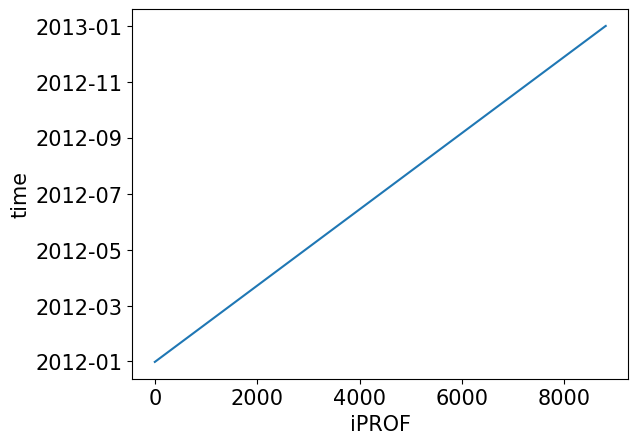

In [54]:
# group profiles by longitude (these are all equatorial TAO moorings)
adcp_by_lon = ds_adcp.groupby('lon')
# check that for a single longitude, time is monotonically increasing 
print(adcp_by_lon)
adcp_by_lon[-140.0].time.plot()

<DatasetGroupBy, grouped over 1 grouper(s), 3 groups in total:
    'lon': 3/3 groups present with labels -170.0, 147.0, 156.0>


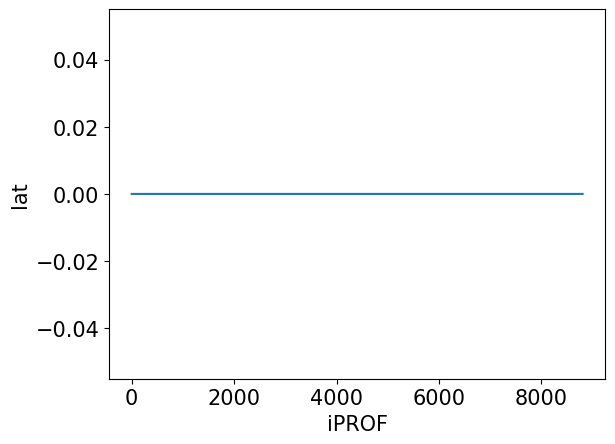

In [55]:
# group profiles by longitude (these are all equatorial TAO moorings)
cur_by_lon = ds_cur.groupby('lon')
# check that for a single longitude, time is monotonically increasing 
print(cur_by_lon)
cur_by_lon[-170.0].lat.plot()

In [14]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
from matplotlib.colors import TwoSlopeNorm
import cmocean.cm as cmo
warnings.filterwarnings("ignore")
plt.rcParams['font.size'] = 15


In [51]:
adcp_by_lon

<xarray.Dataset> Size: 125MB
Dimensions:        (iPROF: 35228, iDEPTH: 62)
Coordinates:
    depth          (iDEPTH) float64 496B -10.0 -15.0 -20.0 ... -310.0 -315.0
    lat            (iPROF) float64 282kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon            (iPROF) float64 282kB -110.0 -110.0 -110.0 ... -170.0 -170.0
  * iPROF          (iPROF) datetime64[ns] 282kB 2011-12-31T01:30:00 ... 2012-...
Dimensions without coordinates: iDEPTH
Data variables:
    prof_YYYYMMDD  (iPROF) float64 282kB 2.011e+07 2.011e+07 ... 2.012e+07
    prof_HHMMSS    (iPROF) float64 282kB 1.3e+04 1.3e+04 ... 2.23e+05 2.23e+05
    prof_lon       (iPROF) float64 282kB -110.0 -110.0 -110.0 ... -170.0 -170.0
    prof_lat       (iPROF) float64 282kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    prof_depth     (iPROF, iDEPTH) float64 17MB 10.0 15.0 20.0 ... 310.0 315.0
    prof_descr     (iPROF) |S30 1MB b'adcp0n110w_hr.cdf             ' ... b'a...
    prof_U         (iPROF, iDEPTH) float64 17MB nan nan nan nan ... nan nan nan
    prof_Uweight   (iPROF, iDEPTH) float64 17MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    prof_V         (iPROF, iDEPTH) float64 17MB nan nan nan nan ... nan nan nan
    prof_Vweight   (iPROF, iDEPTH) float64 17MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    prof_Uestim    (iPROF, iDEPTH) float64 17MB nan nan nan ... -0.0003 -0.01512
    prof_Vestim    (iPROF, iDEPTH) float64 17MB nan nan nan ... 0.05594 0.06204
Attributes:
    Format:   The contents of this MITprof file were processed \nusing the MI...
    date:     08-Sep-2025

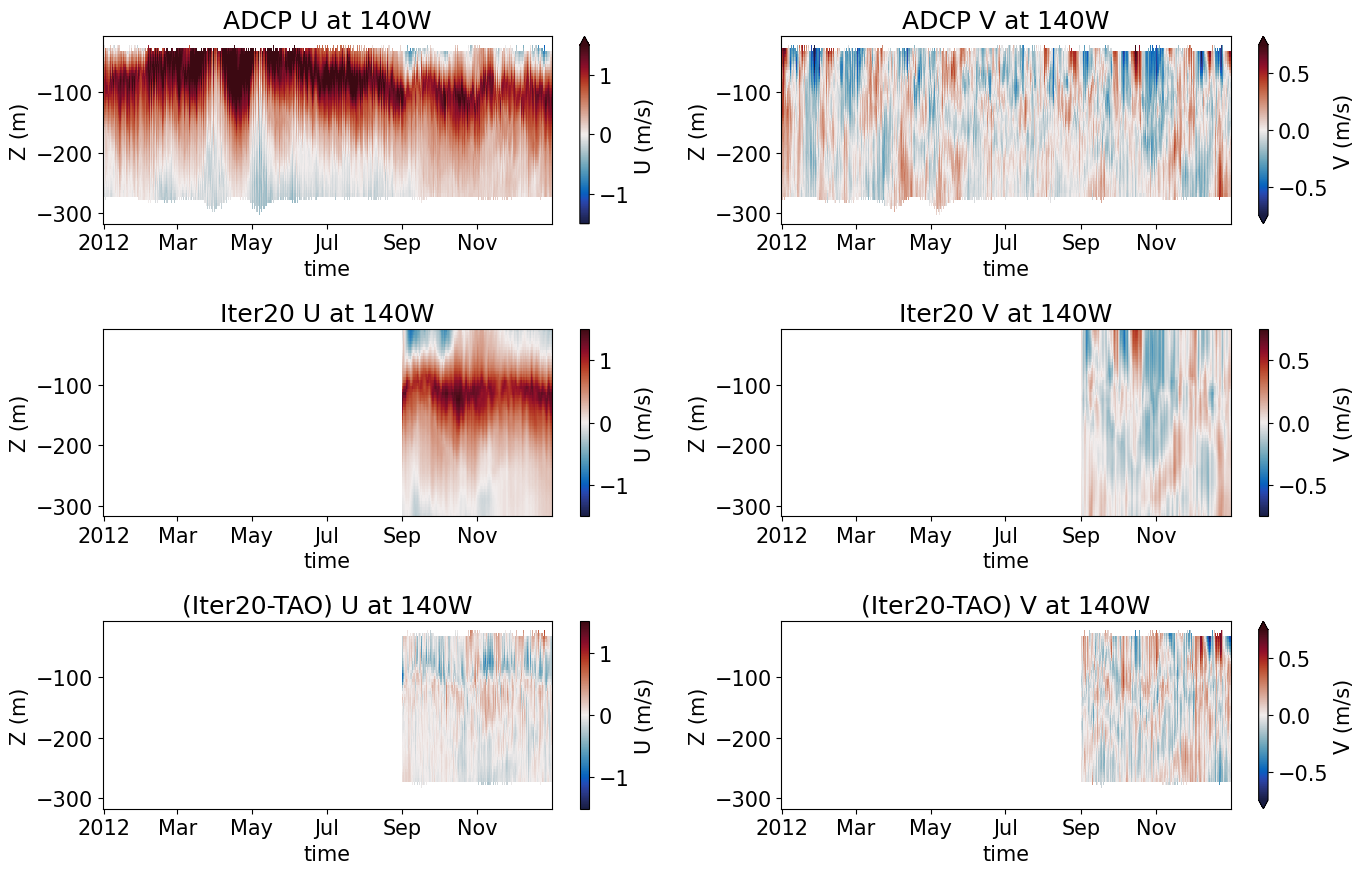

In [16]:
fig, ax = plt.subplots(figsize=(14,9),nrows=3, ncols=2)
adcp_by_lon[-140.0].prof_U.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[0,0].set_title('ADCP U at 140W')
ax[0,0].set_ylabel('Z (m)')
adcp_by_lon[-140.0].prof_Uestim.plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' U at 140W')
diff = adcp_by_lon[-140.0].prof_Uestim - adcp_by_lon[-140.0].prof_U
diff.plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) U at 140W')
ax[2,0].set_ylabel('Z (m)')

adcp_by_lon[-140.0].prof_V.plot(ax=ax[0,1],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[0,1].set_title('ADCP V at 140W')
ax[0,1].set_ylabel('Z (m)')
adcp_by_lon[-140.0].prof_Vestim.plot(ax=ax[1,1],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[1,1].set_ylabel('Z (m)')
ax[1,1].set_title('Iter'+ str(iter)+' V at 140W')
diff = adcp_by_lon[-140.0].prof_Vestim - adcp_by_lon[-140.0].prof_V
diff.T.plot(ax=ax[2,1],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) V at 140W')
ax[2,1].set_ylabel('Z (m)')

plt.tight_layout()
filename = foldername + 'adcp_profiles_vs_iter'+ str(iter)+'.png'
plt.savefig(filename)

In [59]:
def slice_by_time_keep_lon(group, start_time):
    """
    Slice a group (Dataset) by time without overwriting lon.
    
    group: xarray Dataset for a single lon
    start_time: np.datetime64 or string
    """
    # Boolean mask along the profile dimension (iPROF)
    mask = group.time >= np.datetime64(start_time)
    
    # Select the profiles, keep all coordinates intact
    return group.isel(iPROF=mask)

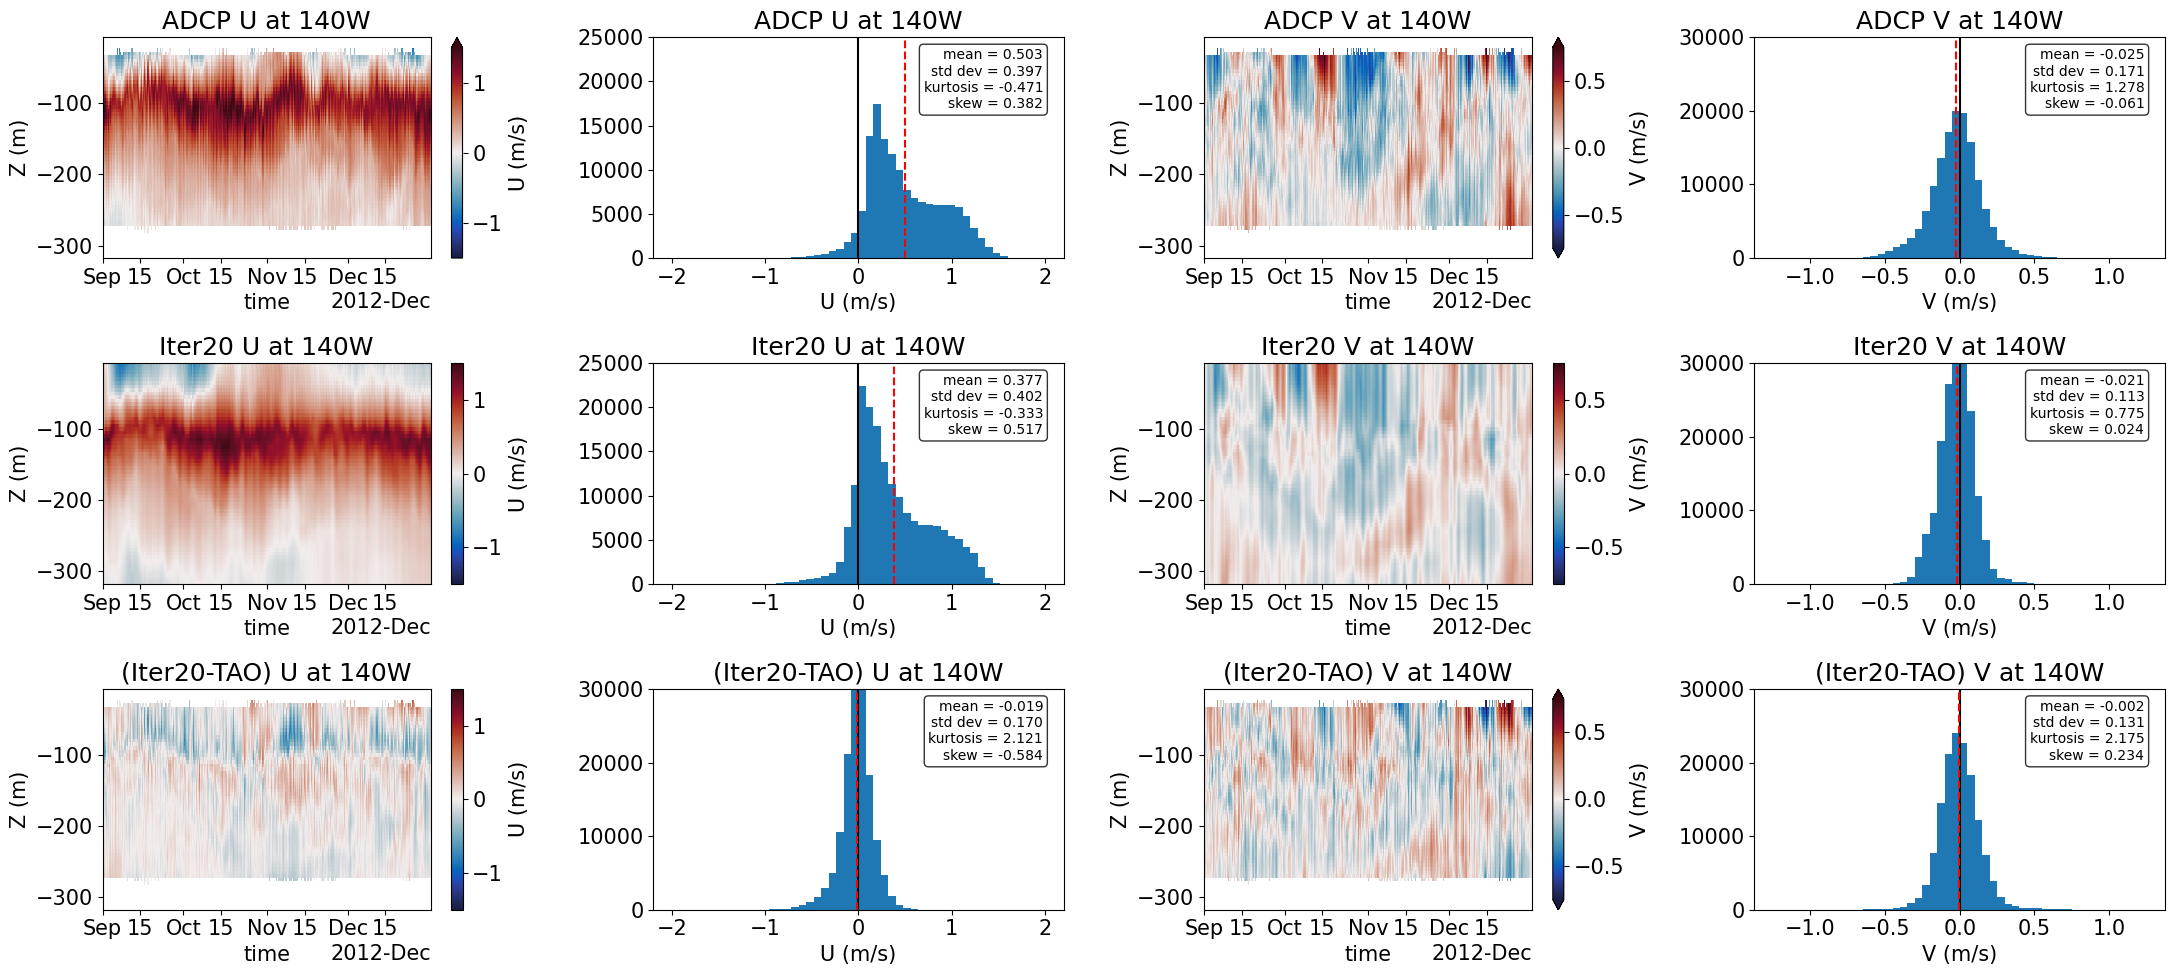

In [61]:
from scipy.stats import kurtosis, skew
vmin = -2.0
vmax = 2.0
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-140.0], "2012-09-01")

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
adcp_by_lon_subset.prof_U.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[0,0].set_title('ADCP U at 140W')
ax[0,0].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Uestim.plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' U at 140W')
diff = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diff[:].plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) U at 140W')
ax[2,0].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_U.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,25000)
ax[0,1].set_title('ADCP U at 140W')
ax[0,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_U.mean().values
std_u = adcp_by_lon_subset.prof_U.std().values
flat_nonan = adcp_by_lon_subset.prof_U.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Uestim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' U at 140W')
ax[1,1].set_ylim(0,25000)
ax[1,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_Uestim.mean().values
std_u = adcp_by_lon_subset.prof_Uestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Uestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) U at 140W')
ax[2,1].set_ylim(0,30000)
ax[2,1].set_xlabel('U (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- V ------------
vmin = -1.25
vmax = 1.25
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

adcp_by_lon_subset.prof_V.plot(ax=ax[0,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[0,2].set_title('ADCP V at 140W')
ax[0,2].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Vestim.plot(ax=ax[1,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' V at 140W')
diff = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
diff[:].plot(ax=ax[2,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) V at 140W')
ax[2,2].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_V.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,30000)
ax[0,3].set_title('ADCP V at 140W')
ax[0,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_V.mean().values
std_u = adcp_by_lon_subset.prof_V.std().values
flat_nonan = adcp_by_lon_subset.prof_V.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Vestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' V at 140W')
ax[1,3].set_ylim(0,30000)
ax[1,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_Vestim.mean().values
std_u = adcp_by_lon_subset.prof_Vestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Vestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) V at 140W')
ax[2,3].set_ylim(0,30000)
ax[2,3].set_xlabel('V (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_hist_140W.png'
plt.savefig(filename)

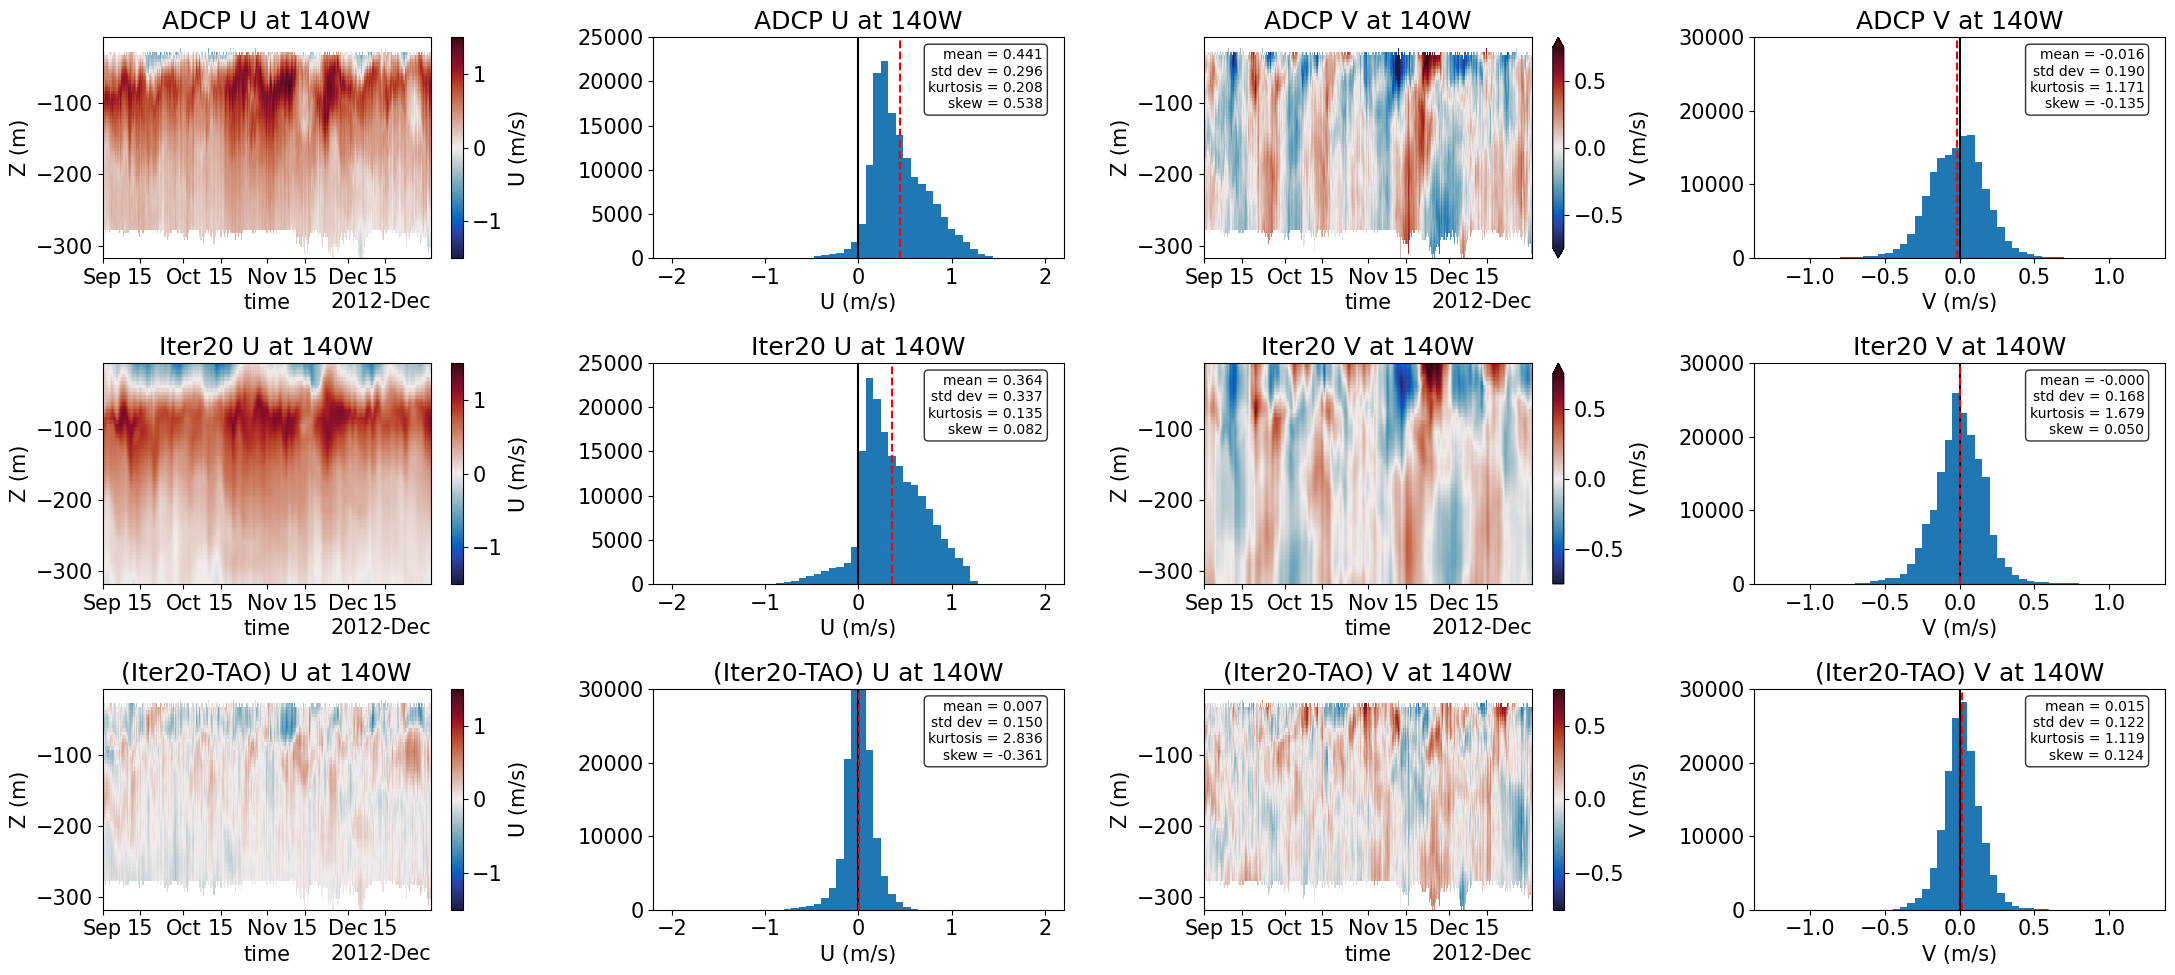

In [62]:
from scipy.stats import kurtosis, skew
vmin = -2.0
vmax = 2.0
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-110.0], "2012-09-01")

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
adcp_by_lon_subset.prof_U.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[0,0].set_title('ADCP U at 140W')
ax[0,0].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Uestim.plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' U at 140W')
diff = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diff[:].plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) U at 140W')
ax[2,0].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_U.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,25000)
ax[0,1].set_title('ADCP U at 140W')
ax[0,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_U.mean().values
std_u = adcp_by_lon_subset.prof_U.std().values
flat_nonan = adcp_by_lon_subset.prof_U.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Uestim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' U at 140W')
ax[1,1].set_ylim(0,25000)
ax[1,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_Uestim.mean().values
std_u = adcp_by_lon_subset.prof_Uestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Uestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) U at 140W')
ax[2,1].set_ylim(0,30000)
ax[2,1].set_xlabel('U (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- V ------------
vmin = -1.25
vmax = 1.25
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

adcp_by_lon_subset.prof_V.plot(ax=ax[0,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[0,2].set_title('ADCP V at 140W')
ax[0,2].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Vestim.plot(ax=ax[1,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' V at 140W')
diff = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
diff[:].plot(ax=ax[2,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) V at 140W')
ax[2,2].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_V.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,30000)
ax[0,3].set_title('ADCP V at 140W')
ax[0,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_V.mean().values
std_u = adcp_by_lon_subset.prof_V.std().values
flat_nonan = adcp_by_lon_subset.prof_V.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Vestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' V at 140W')
ax[1,3].set_ylim(0,30000)
ax[1,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_Vestim.mean().values
std_u = adcp_by_lon_subset.prof_Vestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Vestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) V at 140W')
ax[2,3].set_ylim(0,30000)
ax[2,3].set_xlabel('V (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_hist_110W.png'
plt.savefig(filename)

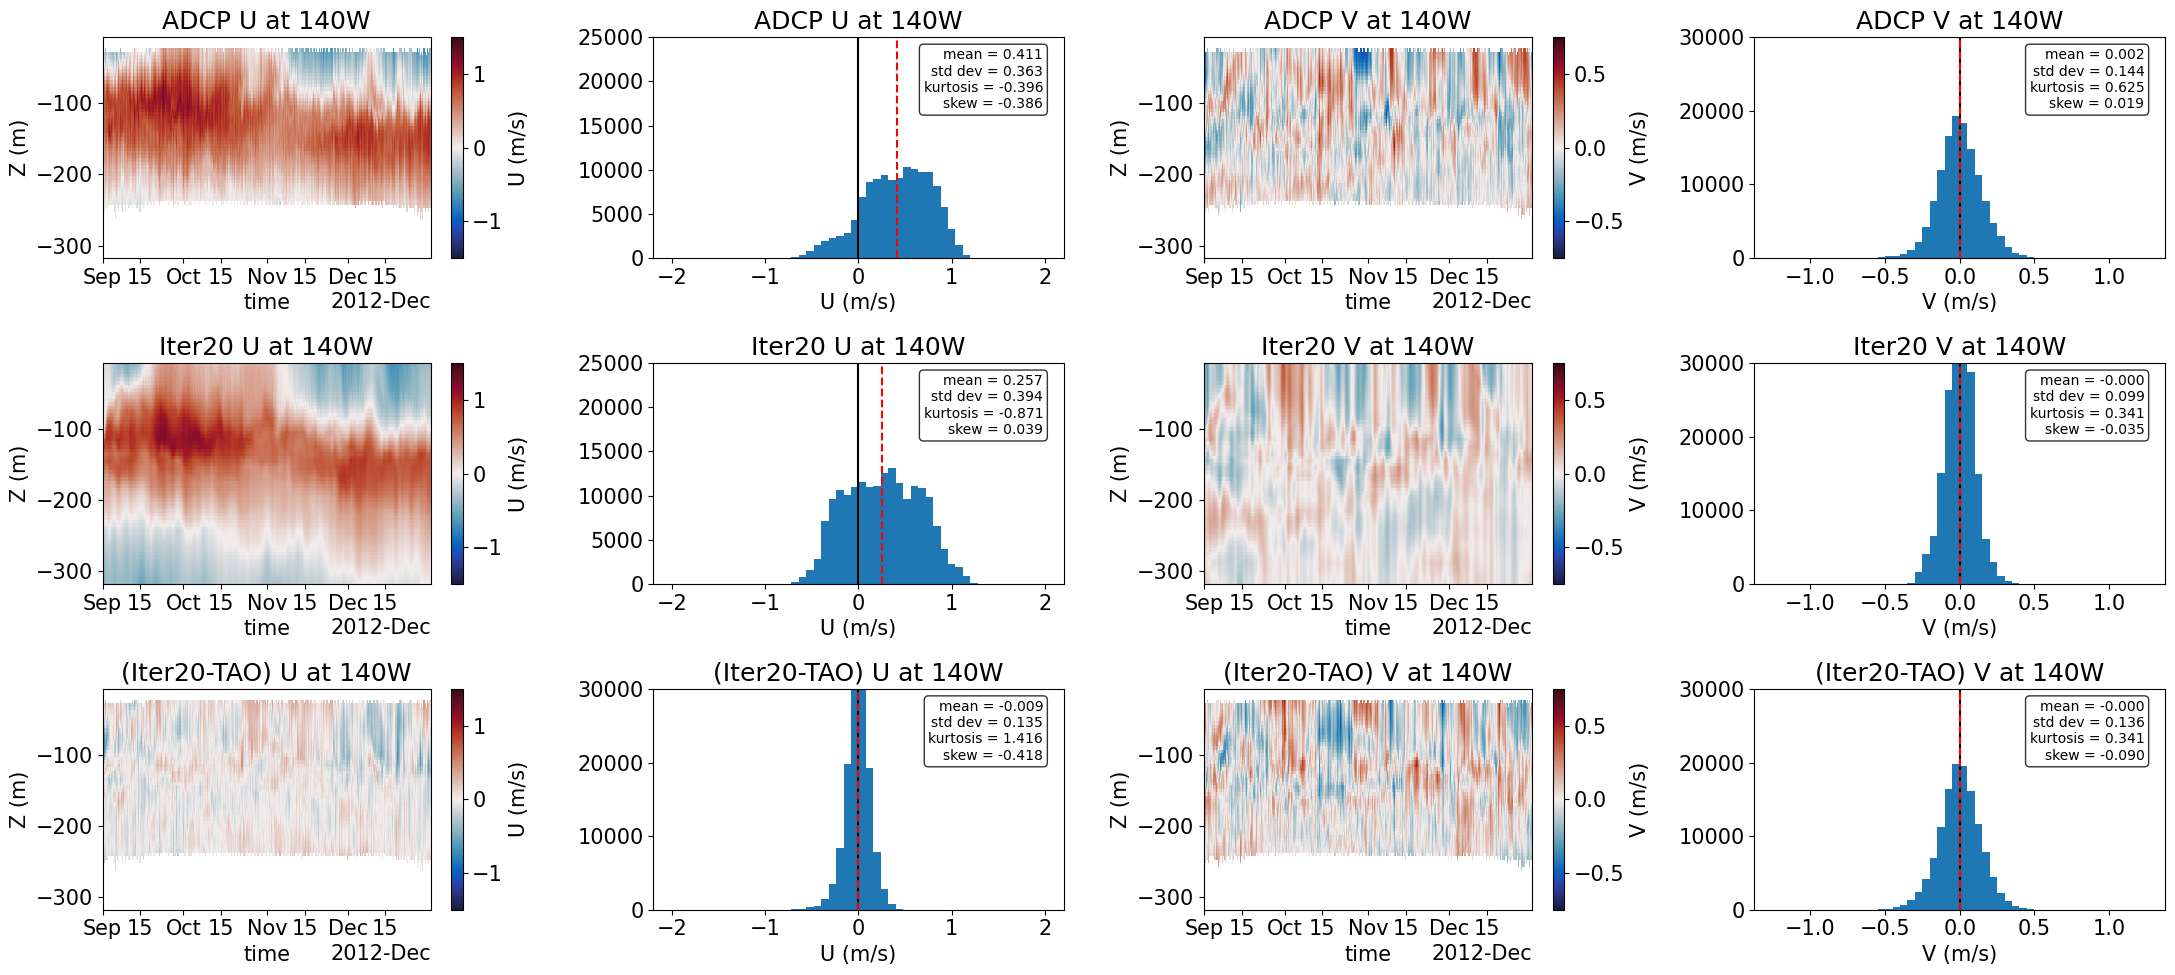

In [63]:
from scipy.stats import kurtosis, skew
vmin = -2.0
vmax = 2.0
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-170.0], "2012-09-01")

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
adcp_by_lon_subset.prof_U.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[0,0].set_title('ADCP U at 140W')
ax[0,0].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Uestim.plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' U at 140W')
diff = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diff[:].plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) U at 140W')
ax[2,0].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_U.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,25000)
ax[0,1].set_title('ADCP U at 140W')
ax[0,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_U.mean().values
std_u = adcp_by_lon_subset.prof_U.std().values
flat_nonan = adcp_by_lon_subset.prof_U.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Uestim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' U at 140W')
ax[1,1].set_ylim(0,25000)
ax[1,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_Uestim.mean().values
std_u = adcp_by_lon_subset.prof_Uestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Uestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) U at 140W')
ax[2,1].set_ylim(0,30000)
ax[2,1].set_xlabel('U (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- V ------------
vmin = -1.25
vmax = 1.25
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

adcp_by_lon_subset.prof_V.plot(ax=ax[0,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[0,2].set_title('ADCP V at 140W')
ax[0,2].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Vestim.plot(ax=ax[1,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' V at 140W')
diff = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
diff[:].plot(ax=ax[2,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) V at 140W')
ax[2,2].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_V.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,30000)
ax[0,3].set_title('ADCP V at 140W')
ax[0,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_V.mean().values
std_u = adcp_by_lon_subset.prof_V.std().values
flat_nonan = adcp_by_lon_subset.prof_V.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Vestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' V at 140W')
ax[1,3].set_ylim(0,30000)
ax[1,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_Vestim.mean().values
std_u = adcp_by_lon_subset.prof_Vestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Vestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) V at 140W')
ax[2,3].set_ylim(0,30000)
ax[2,3].set_xlabel('V (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_hist_170W.png'
plt.savefig(filename)